## PHASE 3: FEATURE ENGINEERING
### Goal: Create new features (columns) that help the model make better predictions
#### What we'll create:
#### 1. Time-based features (year, month, day of week, etc.)
#### 2. Cyclical features (capturing repeating patterns)
#### 3. Lag features (yesterday's sales)
#### 4. Rolling averages (trends)
#### 5. Business logic features (weekends, seasons, etc.)

In [1]:
import os
# Ensure CWD is always the project root regardless of how the notebook is launched
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')


Working directory: /Users/paarth_ganesh/Documents/ML-Projects/sales-forecasting-dashboard


In [2]:
import os
# Ensure CWD is always the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*70)
print("PHASE 3: FEATURE ENGINEERING")
print("="*70)
print("\nLibraries imported!")

PHASE 3: FEATURE ENGINEERING

Libraries imported!


In [3]:
"""
STEP 1: Load the cleaned data from Phase 2
"""

# Load cleaned data
df = pd.read_csv('data/processed/sales_data_clean.csv')

# Convert Date back to datetime (CSV saves it as text)
df['Date'] = pd.to_datetime(df['Date'])

print("="*70)
print("CLEANED DATA LOADED")
print("="*70)
print(f"Shape: {df.shape}")
print(f"\nCurrent columns: {df.columns.tolist()}")

CLEANED DATA LOADED
Shape: (17520, 4)

Current columns: ['Date', 'Product', 'Region', 'Sales']


In [4]:
"""
STEP 2: Extract basic time features from the Date column

These are the building blocks for understanding time patterns.
"""

print("="*70)
print("CREATING BASIC TIME FEATURES")
print("="*70)

# Extract year
df['Year'] = df['Date'].dt.year

# Extract month (1-12)
df['Month'] = df['Date'].dt.month

# Extract month name (January, February, etc.)
df['Month_Name'] = df['Date'].dt.month_name()

# Extract day of month (1-31)
df['Day'] = df['Date'].dt.day

# Extract day of week (0=Monday, 6=Sunday)
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Extract day name (Monday, Tuesday, etc.)
df['Day_Name'] = df['Date'].dt.day_name()

# Extract quarter (1, 2, 3, 4)
df['Quarter'] = df['Date'].dt.quarter

# Extract day of year (1-365)
df['DayOfYear'] = df['Date'].dt.dayofyear

# Extract week of year (1-52)
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

print("Basic time features created!")
print(f"\nNew columns added: 9")
print("\nSample data with new features:")
print(df[['Date', 'Year', 'Month', 'Month_Name', 'Day_Name', 'Quarter']].head(10))

CREATING BASIC TIME FEATURES
Basic time features created!

New columns added: 9

Sample data with new features:
        Date  Year  Month Month_Name Day_Name  Quarter
0 2021-01-01  2021      1    January   Friday        1
1 2021-01-01  2021      1    January   Friday        1
2 2021-01-01  2021      1    January   Friday        1
3 2021-01-01  2021      1    January   Friday        1
4 2021-01-01  2021      1    January   Friday        1
5 2021-01-01  2021      1    January   Friday        1
6 2021-01-01  2021      1    January   Friday        1
7 2021-01-01  2021      1    January   Friday        1
8 2021-01-01  2021      1    January   Friday        1
9 2021-01-01  2021      1    January   Friday        1


In [5]:
"""
STEP 3: Create binary features (0 or 1, No or Yes)

These help the model learn specific patterns like:
"Are weekends different from weekdays?"
"Is December special?"
"""

print("="*70)
print("CREATING BINARY FEATURES")
print("="*70)

# Is it a weekend? (Saturday=5 or Sunday=6)
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Is it Monday? (start of work week)
df['Is_Monday'] = (df['DayOfWeek'] == 0).astype(int)

# Is it Friday? (end of work week)
df['Is_Friday'] = (df['DayOfWeek'] == 4).astype(int)

# Is it the start of month? (Day 1-5)
df['Is_Month_Start'] = (df['Day'] <= 5).astype(int)

# Is it the end of month? (Day 25-31)
df['Is_Month_End'] = (df['Day'] >= 25).astype(int)

# Is it Q4? (Holiday season: Oct, Nov, Dec)
df['Is_Q4'] = (df['Quarter'] == 4).astype(int)

# Is it December specifically?
df['Is_December'] = (df['Month'] == 12).astype(int)

print("Binary features created!")
print("\nSample data:")
sample = df[['Date', 'Day_Name', 'Is_Weekend', 'Is_Monday', 'Is_Friday', 'Is_Q4']].head(10)
print(sample)

# Summary statistics
print("\nBinary Feature Statistics:")
print(f"   Weekend days: {df['Is_Weekend'].sum()} ({df['Is_Weekend'].mean()*100:.1f}%)")
print(f"   Q4 days: {df['Is_Q4'].sum()} ({df['Is_Q4'].mean()*100:.1f}%)")
print(f"   December days: {df['Is_December'].sum()} ({df['Is_December'].mean()*100:.1f}%)")

CREATING BINARY FEATURES
Binary features created!

Sample data:
        Date Day_Name  Is_Weekend  Is_Monday  Is_Friday  Is_Q4
0 2021-01-01   Friday           0          0          1      0
1 2021-01-01   Friday           0          0          1      0
2 2021-01-01   Friday           0          0          1      0
3 2021-01-01   Friday           0          0          1      0
4 2021-01-01   Friday           0          0          1      0
5 2021-01-01   Friday           0          0          1      0
6 2021-01-01   Friday           0          0          1      0
7 2021-01-01   Friday           0          0          1      0
8 2021-01-01   Friday           0          0          1      0
9 2021-01-01   Friday           0          0          1      0

Binary Feature Statistics:
   Weekend days: 5024 (28.7%)
   Q4 days: 4416 (25.2%)
   December days: 1488 (8.5%)


CREATING TREND FEATURE
Trend feature created!

Sample data:
        Date  Days_Since_Start    Sales
0 2021-01-01                 0  1742.99
1 2021-01-01                 0  1030.22
2 2021-01-01                 0   866.71
3 2021-01-01                 0   792.90
4 2021-01-01                 0  1135.93
5 2021-01-01                 0   732.19
6 2021-01-01                 0   737.07
7 2021-01-01                 0   819.65
8 2021-01-01                 0   790.62
9 2021-01-01                 0   910.54

Date range:
  First date: 2021-01-01 → Days_Since_Start = 0
  Last date:  2023-12-31 → Days_Since_Start = 1094
  Total days: 1095


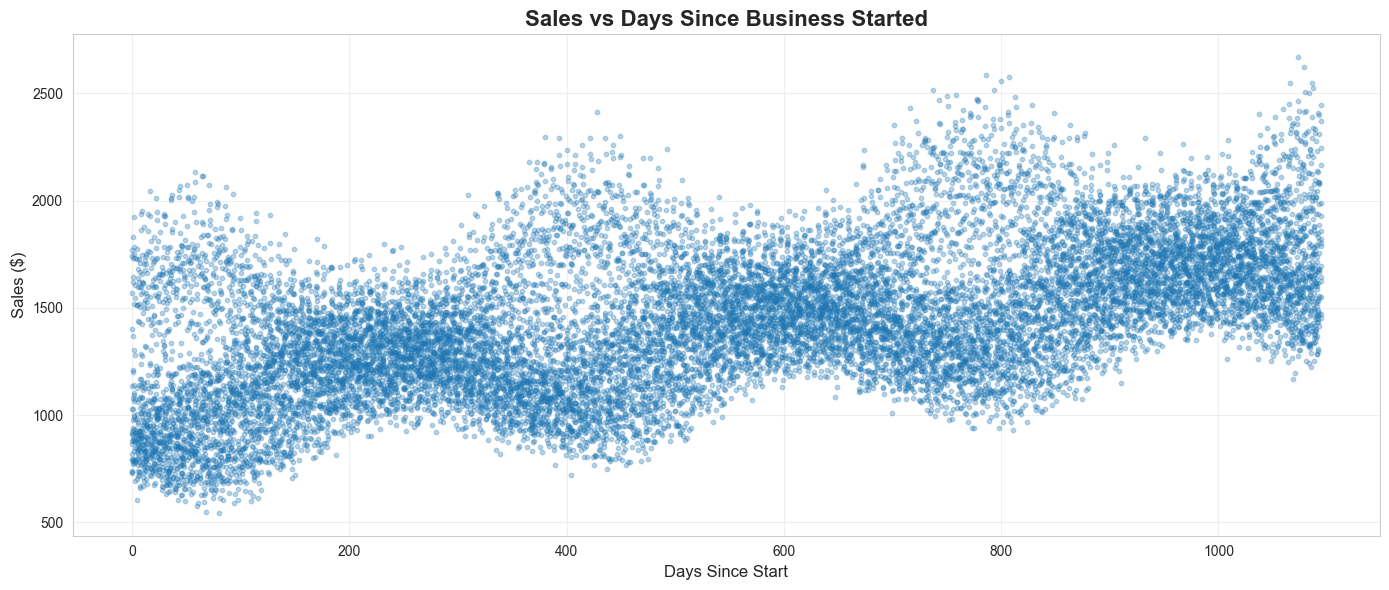


INSIGHT: The upward trend shows business is growing over time!


In [6]:
"""
STEP 4: Create trend feature

This captures business growth over time.
Day 0 = First day of business
Day 1095 = Three years later

The model can learn: "As days increase, sales increase"
"""

print("="*70)
print("CREATING TREND FEATURE")
print("="*70)

# Calculate days since the first date in dataset
df['Days_Since_Start'] = (df['Date'] - df['Date'].min()).dt.days

print("Trend feature created!")
print("\nSample data:")
print(df[['Date', 'Days_Since_Start', 'Sales']].head(10))

print(f"\nDate range:")
print(f"  First date: {df['Date'].min().date()} → Days_Since_Start = 0")
print(f"  Last date:  {df['Date'].max().date()} → Days_Since_Start = {df['Days_Since_Start'].max()}")
print(f"  Total days: {df['Days_Since_Start'].max() + 1}")

# Visualize trend
plt.figure(figsize=(14, 6))
plt.scatter(df['Days_Since_Start'], df['Sales'], alpha=0.3, s=10)
plt.xlabel('Days Since Start', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.title('Sales vs Days Since Business Started', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT: The upward trend shows business is growing over time!")

In [7]:
"""
STEP 5: Create lag features

Lag = Previous values
"Lag 1" = Yesterday's sales (for same Product + Region)
"Lag 7" = Same day last week
"Lag 14" = Same day two weeks ago
"Lag 30" = Same day last month

Why per-product-region? Electronics in the East follow a different
pattern from Clothing in the West, so mixing them gives incorrect lags.
"""

print("="*70)
print("⏮️ CREATING LAG FEATURES (per Product-Region group)")
print("="*70)

# Sort so groupby shifts work correctly
df = df.sort_values(["Product", "Region", "Date"]).reset_index(drop=True)

# Group by Product and Region so each series gets its own correct lags
grp = df.groupby(["Product", "Region"])["Sales"]

# Sales from yesterday (Lag 1)
df["Lag_1"]  = grp.shift(1)

# Sales from 7 days ago (same day last week)
df["Lag_7"]  = grp.shift(7)

# Sales from 14 days ago (two weeks ago)
df["Lag_14"] = grp.shift(14)

# Sales from 30 days ago (roughly same day last month)
df["Lag_30"] = grp.shift(30)

print("Lag features created!")
print("\nSample data (notice NaN for first rows in each group — no prior history):")
print(df[["Date", "Product", "Region", "Sales", "Lag_1", "Lag_7", "Lag_14", "Lag_30"]].head(35))


⏮️ CREATING LAG FEATURES
Lag features created!

Sample data (notice NaN for first rows - they have no 'yesterday'):
         Date    Sales  Sales_Lag_1  Sales_Lag_7  Sales_Lag_30
0  2021-01-01  1742.99          NaN          NaN           NaN
1  2021-01-01  1030.22      1742.99          NaN           NaN
2  2021-01-01   866.71      1030.22          NaN           NaN
3  2021-01-01   792.90       866.71          NaN           NaN
4  2021-01-01  1135.93       792.90          NaN           NaN
5  2021-01-01   732.19      1135.93          NaN           NaN
6  2021-01-01   737.07       732.19          NaN           NaN
7  2021-01-01   819.65       737.07      1742.99           NaN
8  2021-01-01   790.62       819.65      1030.22           NaN
9  2021-01-01   910.54       790.62       866.71           NaN
10 2021-01-01   728.76       910.54       792.90           NaN
11 2021-01-01   877.64       728.76      1135.93           NaN
12 2021-01-01  1769.42       877.64       732.19           NaN
13

CREATING ROLLING AVERAGE FEATURES
Rolling features created!

Sample data:
         Date    Sales   Sales_MA_7  Sales_MA_30  Sales_Std_7
0  2021-01-01  1742.99          NaN          NaN          NaN
1  2021-01-01  1030.22          NaN          NaN          NaN
2  2021-01-01   866.71          NaN          NaN          NaN
3  2021-01-01   792.90          NaN          NaN          NaN
4  2021-01-01  1135.93          NaN          NaN          NaN
5  2021-01-01   732.19          NaN          NaN          NaN
6  2021-01-01   737.07  1005.430000          NaN   358.870676
7  2021-01-01   819.65   873.524286          NaN   153.544026
8  2021-01-01   790.62   839.295714          NaN   138.788217
9  2021-01-01   910.54   845.557143          NaN   141.198903
10 2021-01-01   728.76   836.394286          NaN   147.141584
11 2021-01-01   877.64   799.495714          NaN    73.431268
12 2021-01-01  1769.42   947.671429          NaN   368.529436
13 2021-01-01  1568.32  1066.421429          NaN   419.726

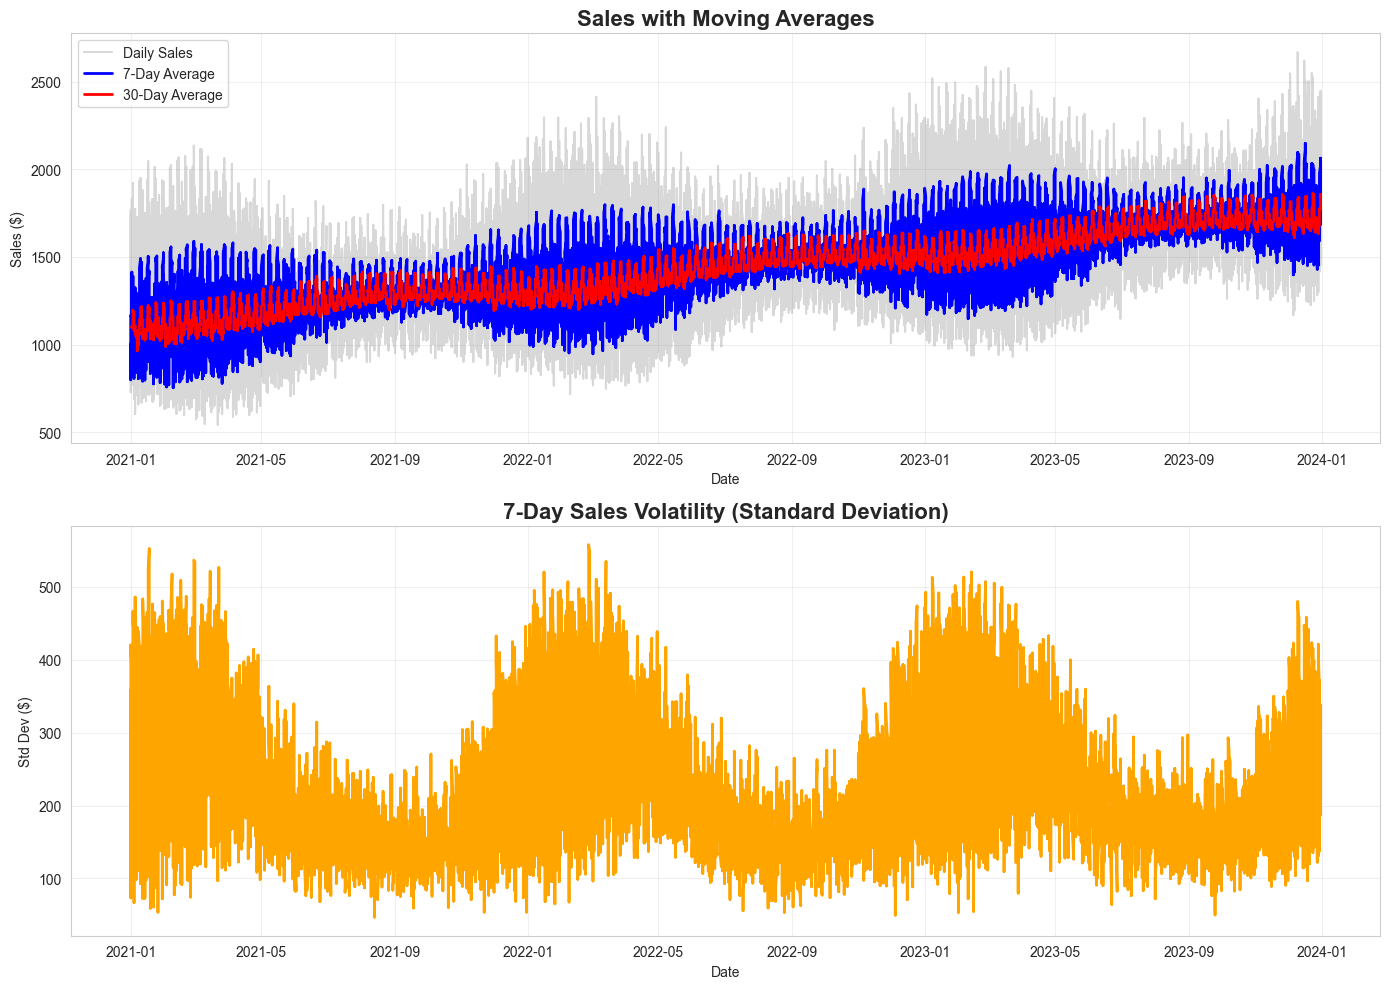


INSIGHT:
   • Blue line (7-day avg) = Short-term trend
   • Red line (30-day avg) = Long-term trend
   • Orange plot = How much sales vary day-to-day


In [8]:
"""
STEP 6: Create rolling average features

Rolling average = Average of last N days (within the same Product-Region group)
Smooths out daily noise and captures trend.

MA_7  = 7-day moving average   (short-term trend)
MA_14 = 14-day moving average  (medium-term trend)
MA_30 = 30-day moving average  (long-term trend)
Std_7 = 7-day rolling std dev  (volatility)

We shift by 1 before rolling so we never leak today's sales into the feature.
"""

print("="*70)
print("CREATING ROLLING AVERAGE FEATURES (per Product-Region group)")
print("="*70)

# 7-day rolling average (short-term weekly trend)
df["MA_7"]  = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())

# 14-day rolling average (medium-term trend)
df["MA_14"] = grp.transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())

# 30-day rolling average (monthly trend)
df["MA_30"] = grp.transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())

# 7-day rolling standard deviation (volatility / uncertainty)
df["Std_7"] = grp.transform(lambda x: x.shift(1).rolling(7, min_periods=2).std())

print("Rolling features created!")
print("\nSample data:")
print(df[["Date", "Product", "Region", "Sales", "MA_7", "MA_14", "MA_30", "Std_7"]].head(35))

# Visualize
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Sales with moving averages (aggregate across all groups for visualisation)
df_agg = df.groupby("Date").agg({"Sales": "mean", "MA_7": "mean", "MA_14": "mean", "MA_30": "mean"}).reset_index()

axes[0].plot(df_agg["Date"], df_agg["Sales"],  alpha=0.3, label="Daily Sales",      color="gray")
axes[0].plot(df_agg["Date"], df_agg["MA_7"],   label="7-Day MA",   color="blue",   linewidth=2)
axes[0].plot(df_agg["Date"], df_agg["MA_14"],  label="14-Day MA",  color="orange", linewidth=2)
axes[0].plot(df_agg["Date"], df_agg["MA_30"],  label="30-Day MA",  color="red",    linewidth=2)
axes[0].set_title("Sales with Moving Averages (all groups averaged)", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Sales ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Volatility
df_std = df.groupby("Date")["Std_7"].mean().reset_index()
axes[1].plot(df_std["Date"], df_std["Std_7"], color="orange", linewidth=2)
axes[1].set_title("7-Day Sales Volatility — Std Dev (averaged across groups)", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Std Dev ($)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINSIGHT:")
print("   • Blue  (7-day)  = Short-term trend")
print("   • Orange (14-day) = Medium-term trend")
print("   • Red   (30-day) = Long-term trend")
print("   • Bottom plot    = How much sales vary day-to-day")


In [9]:
"""
STEP 7: Review all features created
"""

print("="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

print(f"\nTotal features created: {len(df.columns) - 4}")
print("   (Original had 4 columns: Date, Product, Region, Sales)")

print("\nFEATURE CATEGORIES:")

print("\nTIME FEATURES (9):")
time_features = ["Year", "Month", "Month_Name", "Day", "DayOfWeek",
                 "Day_Name", "Quarter", "DayOfYear", "WeekOfYear"]
print(f"   {', '.join(time_features)}")

print("\nBINARY FEATURES (7):")
binary_features = ["Is_Weekend", "Is_Monday", "Is_Friday", "Is_Month_Start",
                   "Is_Month_End", "Is_Q4", "Is_December"]
print(f"   {', '.join(binary_features)}")

print("\nTREND FEATURES (1):")
print("   Days_Since_Start")

print("\nLAG FEATURES (4):")
lag_features = ["Lag_1", "Lag_7", "Lag_14", "Lag_30"]
print(f"   {', '.join(lag_features)}")

print("\nROLLING FEATURES (4):")
rolling_features = ["MA_7", "MA_14", "MA_30", "Std_7"]
print(f"   {', '.join(rolling_features)}")

print(f"\nCurrent dataset shape: {df.shape}")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# Show all columns
print("\nALL COLUMNS:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\nNOTE: NaN values will appear for the first rows in each Product-Region group")
print("      (lag startup window). These are dropped before saving.")


FEATURE ENGINEERING SUMMARY

Total features created: 23
   (Original had 4 columns: Date, Product, Region, Sales)

FEATURE CATEGORIES:

TIME FEATURES (9):
   Year, Month, Month_Name, Day, DayOfWeek, Day_Name, Quarter, DayOfYear, WeekOfYear

BINARY FEATURES (7):
   Is_Weekend, Is_Monday, Is_Friday, Is_Month_Start, Is_Month_End, Is_Q4, Is_December

TREND FEATURES (1):
   Days_Since_Start

LAG FEATURES (3):
   Sales_Lag_1, Sales_Lag_7, Sales_Lag_30

ROLLING FEATURES (3):
   Sales_MA_7, Sales_MA_30, Sales_Std_7

Current dataset shape: (17520, 27)
   Rows: 17520
   Columns: 27

ALL COLUMNS:
    1. Date
    2. Product
    3. Region
    4. Sales
    5. Year
    6. Month
    7. Month_Name
    8. Day
    9. DayOfWeek
   10. Day_Name
   11. Quarter
   12. DayOfYear
   13. WeekOfYear
   14. Is_Weekend
   15. Is_Monday
   16. Is_Friday
   17. Is_Month_Start
   18. Is_Month_End
   19. Is_Q4
   20. Is_December
   21. Days_Since_Start
   22. Sales_Lag_1
   23. Sales_Lag_7
   24. Sales_Lag_30
   25. S

In [10]:
"""
STEP 8: Handle NaN values created by lag and rolling features

Remember:
- First row has no "yesterday" (lag features → NaN)
- First 7 rows in each group have no 7-day MA (rolling → NaN)
- First 14 rows have no 14-day MA
- First 30 rows have no 30-day MA

Common approaches:
1. Drop rows with NaN (simple, loses data)
2. Fill with 0 or mean (keeps data, but might distort)
3. Use only complete data for modeling (best for now)
"""

print("="*70)
print("HANDLING MISSING VALUES")
print("="*70)

# Check how many NaN values we have
print("\nMissing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0]  # Only show columns with NaN
print(missing)

print(f"\nTotal rows: {len(df)}")
print(f"Rows with ANY NaN: {df.isnull().any(axis=1).sum()}")

# For modeling, we'll need complete data
# Let's see how much we lose if we drop NaN rows
df_clean = df.dropna()

print(f"\nAfter removing rows with NaN:")
print(f"   Remaining rows: {len(df_clean)}")
print(f"   Rows removed: {len(df) - len(df_clean)}")
print(f"   Percentage kept: {len(df_clean)/len(df)*100:.1f}%")

# Use the clean version going forward
df = df_clean.copy()

HANDLING MISSING VALUES

Missing values per column:
Sales_Lag_1      1
Sales_Lag_7      7
Sales_Lag_30    30
Sales_MA_7       6
Sales_MA_30     29
Sales_Std_7      6
dtype: int64

Total rows: 17520
Rows with ANY NaN: 30

After removing rows with NaN:
   Remaining rows: 17490
   Rows removed: 30
   Percentage kept: 99.8%


In [11]:
"""
STEP 9: Save the feature-engineered dataset
"""

print("="*70)
print("SAVING FEATURE-ENGINEERED DATA")
print("="*70)

# Save to processed folder
output_path = 'data/processed/sales_features.csv'
df.to_csv(output_path, index=False)

print("NOTE: Lag/MA columns are named Lag_X / MA_X / Std_7 to match NB04 and app.py")
print(f"Feature-engineered data saved to:")
print(f"   {output_path}")
print(f"\nFinal dataset stats:")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Quick preview
print("\nFirst few rows of final dataset:")
print(df.head())

SAVING FEATURE-ENGINEERED DATA
Feature-engineered data saved to:
   data/processed/sales_features.csv

Final dataset stats:
   Rows: 17,490
   Columns: 27
   Date range: 2021-01-02 to 2023-12-31
   Memory: 6606.38 KB

First few rows of final dataset:
         Date      Product Region    Sales  Year  Month Month_Name  Day  \
30 2021-01-02  Electronics  North  1832.35  2021      1    January    2   
31 2021-01-02     Clothing   West   940.48  2021      1    January    2   
32 2021-01-03         Food  South   791.79  2021      1    January    3   
33 2021-01-03    Furniture   West  1302.98  2021      1    January    3   
34 2021-01-03    Furniture   East  1092.63  2021      1    January    3   

    DayOfWeek  Day_Name  Quarter  DayOfYear  WeekOfYear  Is_Weekend  \
30          5  Saturday        1          2          53           1   
31          5  Saturday        1          2          53           1   
32          6    Sunday        1          3          53           1   
33          6 